In [33]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
#movie dataset analysis assignment
#1 explore the dataset
movies = pd.read_csv("movies.csv")
movies.head()
movies.info()
movies.describe



<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       4000 non-null   str    
 1   rating     3960 non-null   str    
 2   genre      4000 non-null   str    
 3   year       4000 non-null   int64  
 4   released   4000 non-null   str    
 5   score      4000 non-null   float64
 6   votes      4000 non-null   int64  
 7   director   4000 non-null   str    
 8   writer     3999 non-null   str    
 9   star       3999 non-null   str    
 10  country    4000 non-null   str    
 11  budget     4000 non-null   int64  
 12  gross      3831 non-null   float64
 13  company    3990 non-null   str    
 14  runtime,,  4000 non-null   str    
dtypes: float64(2), int64(3), str(10)
memory usage: 468.9 KB


<bound method NDFrame.describe of                                                 name rating      genre  year  \
0                                        The Shining      R      Drama  1980   
1                                    The Blue Lagoon      R  Adventure  1980   
2     Star Wars: Episode V - The Empire Strikes Back     PG     Action  1980   
3                                          Airplane!     PG     Comedy  1980   
4                                         Caddyshack      R     Comedy  1980   
...                                              ...    ...        ...   ...   
3995                                   Birthday Girl      R     Comedy  2001   
3996                                    Human Nature      R     Comedy  2001   
3997                                            Made      R     Comedy  2001   
3998                           One Night at McCool's      R     Comedy  2001   
3999                                  Dr. Dolittle 2     PG     Comedy  2001   

     

In [ ]:

print("1 Total movies:", len(movies))
print("2 numerical columns: ", movies.select_dtypes(include='number').columns)
print("3 categorical columns:", movies.select_dtypes(include='string').columns)


1 Total movies: 4000
2 numerical columns:  Index(['year', 'score', 'votes', 'budget', 'gross'], dtype='str')
3 categorical columns: Index(['name', 'rating', 'genre', 'released', 'director', 'writer', 'star',
       'country', 'company', 'runtime,,'],
      dtype='str')


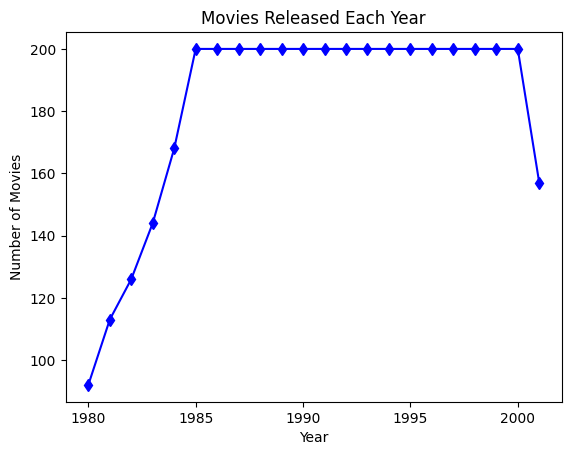

1 first year with the highest number of movies is:  1985
Number of movies: 200
2 yes, number of movies increases from 1980 to years
3 movie production increased in early years , stayed stable for years and then finally decline in 2001


In [36]:
#2 number of movies released each year 

year_movies = movies["year"].value_counts().sort_index()
plt.plot(year_movies.index, year_movies.values, marker='d',color='blue')

plt.title("Movies Released Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()
print("1 first year with the highest number of movies is: ", year_movies.idxmax())    
print("Number of movies:", year_movies.max())
print("2 yes, number of movies increases from 1980 to years")
print("3 movie production increased in early years , stayed stable for years and then finally decline in 2001")






In [37]:
print(year_movies)

year
1980     92
1981    113
1982    126
1983    144
1984    168
1985    200
1986    200
1987    200
1988    200
1989    200
1990    200
1991    200
1992    200
1993    200
1994    200
1995    200
1996    200
1997    200
1998    200
1999    200
2000    200
2001    157
Name: count, dtype: int64


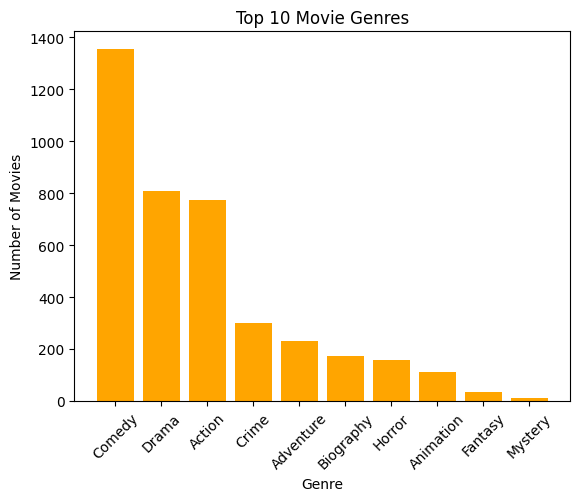

1 Genre with the most movies: Comedy
2 Genre with the fewest movies among the top 10: Mystery
3 bar chart is suitable because it compares the number of movies in each genre clearly.


In [39]:
# 3 Top 10 Movie Genres

top_genres = movies["genre"].value_counts().head(10)

plt.bar(top_genres.index, top_genres.values, color="orange")
plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

print("1 Genre with the most movies:", top_genres.idxmax())
print("2 Genre with the fewest movies among the top 10:", top_genres.idxmin())
print("3 bar chart is suitable because it compares the number of movies in each genre clearly.")

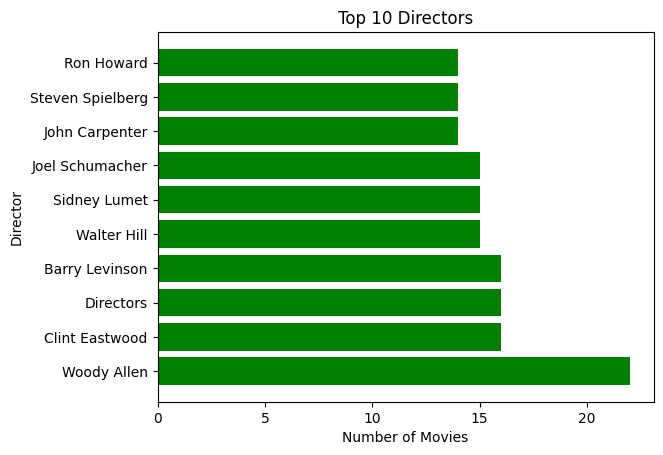

1 Director with the most movies: Woody Allen
2 A horizontal bar chart is better because director names are long and easier to read.


In [41]:
# 4 Top 10 Directors

top_directors = movies["director"].value_counts().head(10)

plt.barh(top_directors.index, top_directors.values, color="green")

plt.title("Top 10 Directors")
plt.xlabel("Number of Movies")
plt.ylabel("Director")
plt.show()

print("1 Director with the most movies:", top_directors.idxmax())
print("2 A horizontal bar chart is better because director names are long and easier to read.")

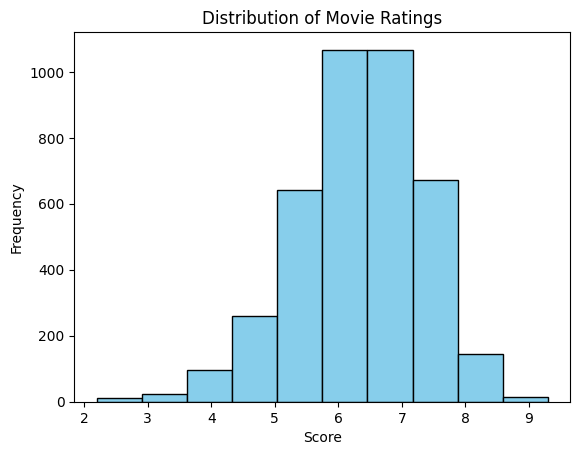

1 The score range with the highest frequency can be identified from the tallest bar.
2 Yes, most movies have ratings between about 6 and 8.
3 No, low-rated movies are less common.
4 The histogram shows that most movies have average to high ratings.


In [42]:
# 5 Distribution of Movie Ratings

plt.hist(movies["score"],bins=10,color="skyblue",edgecolor="black")

plt.title("Distribution of Movie Ratings")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

print("1 The score range with the highest frequency can be identified from the tallest bar.")
print("2 Yes, most movies have ratings between about 6 and 8.")
print("3 No, low-rated movies are less common.")
print("4 The histogram shows that most movies have average to high ratings.")

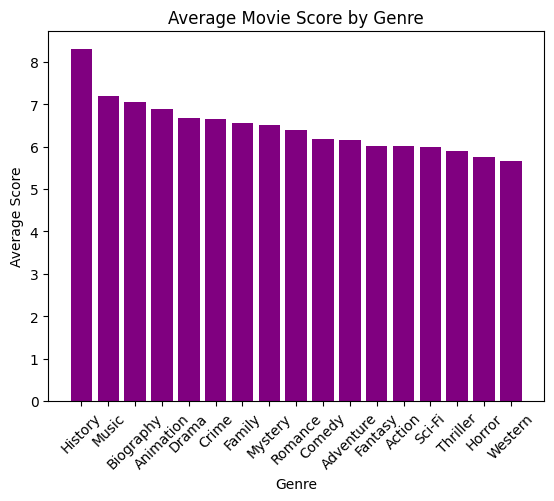

1 Genre with the highest average score: History
2 Genre with the lowest average score: Western
3 Not always. The most popular genres are not necessarily the highest rated.


In [43]:
# 6average Movie Score by Genre

avg_score = movies.groupby("genre")["score"].mean().sort_values(ascending=False)

plt.bar(avg_score.index, avg_score.values, color="purple")

plt.title("Average Movie Score by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()

print("1 Genre with the highest average score:", avg_score.idxmax())
print("2 Genre with the lowest average score:", avg_score.idxmin())
print("3 Not always. The most popular genres are not necessarily the highest rated.")

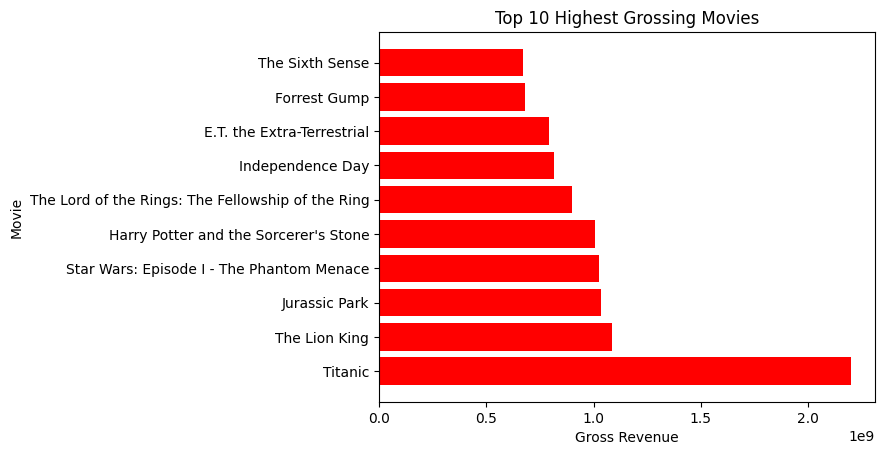

1 Highest grossing movie: Titanic
2 Yes, there is a noticeable difference between the highest-grossing movie and the others.
3 The graph shows that a few blockbuster movies earned much more revenue than the rest.


In [44]:
# 7 Top 10 Highest Grossing Movies

top_gross = movies.nlargest(10, "gross")

plt.barh(top_gross["name"],top_gross["gross"],color="red")

plt.title("Top 10 Highest Grossing Movies")
plt.xlabel("Gross Revenue")
plt.ylabel("Movie")
plt.show()

print("1 Highest grossing movie:", top_gross.iloc[0]["name"])
print("2 Yes, there is a noticeable difference between the highest-grossing movie and the others.")
print("3 The graph shows that a few blockbuster movies earned much more revenue than the rest.")

In [45]:
print("Comedy is the most common genre, " \
"while History has the highest average movie rating. " \
"Most movies have ratings between 6 and 8, which shows that " \
"the majority of movies are fairly well received, and only a " \
"small number have very low ratings. The number of movies released" \
" increased from 1980 to 1985, stayed almost the same for many" \
" years, and then dropped in 2001. I also found that Titanic"
" is the highest-grossing movie in the dataset, earning much " \
"more than most of the other movies. Based on these results," \
" I would recommend that movie studios continue making " \
"popular genres like Comedy while also creating more " \
"high-quality movies similar to those in the History genre." \
" Producing well-written, high-quality films can help attract" \
" more viewers and improve box office success.")

Comedy is the most common genre, while History has the highest average movie rating. Most movies have ratings between 6 and 8, which shows that the majority of movies are fairly well received, and only a small number have very low ratings. The number of movies released increased from 1980 to 1985, stayed almost the same for many years, and then dropped in 2001. I also found that Titanic is the highest-grossing movie in the dataset, earning much more than most of the other movies. Based on these results, I would recommend that movie studios continue making popular genres like Comedy while also creating more high-quality movies similar to those in the History genre. Producing well-written, high-quality films can help attract more viewers and improve box office success.
